# **IMPORT NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# **LOAD DATASET**

In [2]:
df = pd.read_csv('cleaned_dataset_final.csv')
df.shape

(82071, 3)

In [3]:
# Ensure 'Review' column is treated as string and 'Rating' as integer
df['Review'] = df['Review'].astype(str)
df['Rating'] = df['Rating'].astype(int)

In [4]:
df.dropna(subset=['Review', 'Rating'], inplace=True)
df.shape

(82071, 3)

# **PREPROCESSING**

In [5]:
# Drop reviews less than 3 words and more than 100 words

df['word_count'] = df['Review'].apply(lambda x: len(x.split()))

# Filter the DataFrame to keep reviews between 3 and 100 words (inclusive)
df_filtered = df[(df['word_count'] >= 3) & (df['word_count'] <= 100)].copy()

print(f"Reviews dropped: {df.shape[0] - df_filtered.shape[0]}")
print(f"Dataset shape after filtering: {df_filtered.shape}")

Reviews dropped: 5425
Dataset shape after filtering: (76646, 4)


# **BALANCING DATASET (3000 REVIEWS PER RATING)**

In [6]:
# Creating a balanced dataset with 5000 reviews per rating
print("\n--- Creating a Balanced Dataset (5000 reviews per rating) ---")

target_count = 3000
balanced_data = []

# Get the unique ratings present in the filtered data
ratings = df_filtered['Rating'].unique()

for rating in sorted(ratings):
    # Filter for the current rating
    rating_subset = df_filtered[df_filtered['Rating'] == rating]

    # Determine the actual sample size (min of target_count or available rows)
    sample_size = min(len(rating_subset), target_count)

    # Sample the required number of rows for this rating
    # random_state ensures reproducibility
    sampled_subset = rating_subset.sample(n=sample_size, random_state=42)
    balanced_data.append(sampled_subset)

# Concatenate all sampled subsets into the final balanced DataFrame
df_balanced = pd.concat(balanced_data).reset_index(drop=True)

print(f"Balanced dataset created. Total reviews: {df_balanced.shape[0]}")
print("Final count per rating in balanced dataset:")
print(df_balanced['Rating'].value_counts().sort_index())


--- Creating a Balanced Dataset (5000 reviews per rating) ---
Balanced dataset created. Total reviews: 15000
Final count per rating in balanced dataset:
Rating
1    3000
2    3000
3    3000
4    3000
5    3000
Name: count, dtype: int64


# **DATA VISUALIZATION**

### BAR PLOT

/tmp/ipython-input-2706750044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df_balanced, palette="viridis", edgecolor='black', zorder=3)


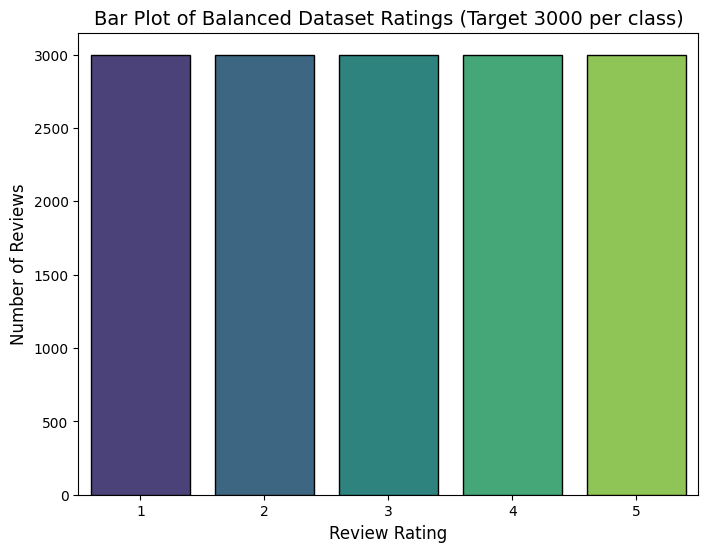

In [7]:
# Bar Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=df_balanced, palette="viridis", edgecolor='black', zorder=3)
plt.title('Bar Plot of Balanced Dataset Ratings (Target 3000 per class)', fontsize=14)
plt.xlabel('Review Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.show()

# **SAMPLE REVIEWS**

In [10]:
for rating in sorted(df_balanced['Rating'].unique()):
    samples = df_balanced[df_balanced['Rating'] == rating].head(5)
    print(f"\nRating {rating} Samples:")
    for i, row in samples.iterrows():
        # Truncate review for cleaner printing
        review_text = row['Review'][:300] + ('...' if len(row['Review']) > 300 else '')
        print(f"  - {review_text}")


Rating 1 Samples:
  - worst model user please buy
  - inferior quality looks cheap
  - bad product product stopped working switch hold soon one presses
  - wood part broken
  - worst materials waste money

Rating 2 Samples:
  - sole shoes badand fabric quality cheap recommend buy product going return
  - qulity use befoure packad item verry bead qulity
  - print proper fabric also per expectations
  - bad product bad sound quality
  - bat quality buy product flipkart return money

Rating 3 Samples:
  - quiet uncertain inverter okay power button work connecting battery soon wire connected battery inverter starts switch dont know z z z z z z
  - satisfied battery backup else everything good
  - awesome worth money good bass nice sound clarity
  - good product value money thanks filipkart team
  - awesome product thank flipkart trust v gaurd super product

Rating 4 Samples:
  - thanks flipkart team wonderful delivery time kind delivery boy product purchased mom happy gifted mom birthday 

# **SAVING DATASET**

In [11]:
print("\nFinalizing and Saving Data")

# Save the final balanced dataset to a CSV file
output_filename = "balanced_dataset_final.csv"
df_balanced.to_csv(output_filename, index=False)
files.download(output_filename)

# Final check of the balanced dataset structure
df_balanced.info()


Finalizing and Saving Data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1704 non-null   float64
 1   Rating      15000 non-null  int64  
 2   Review      15000 non-null  object 
 3   word_count  15000 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 468.9+ KB
